# California Residential Home Price Prediction
# Model Evaluation and Explainability

This notebook evaluates and explains the final XGBoost model from the previous notebook, covering feature importance, SHAP based explanations, price band performance, and practical deployment considerations like model size and prediction latency.

In [16]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import r2_score, mean_absolute_percentage_error
import matplotlib.pyplot as plt
import shap

## Section 1 - Setup and Loading the Final Model

In [12]:
df_model = pd.read_csv('data/cleaned_data_final.csv')

latest_month = df_model['CloseYear'] * 100 + df_model['CloseMonth']
test_month = latest_month.max()

df_train = df_model[latest_month != test_month].copy()
df_test = df_model[latest_month == test_month].copy()

X_train = df_train.drop(columns=['ClosePrice'])
y_train = df_train['ClosePrice']
X_test = df_test.drop(columns=['ClosePrice'])
y_test = df_test['ClosePrice']

model = xgb.XGBRegressor()
model.load_model('data/xgboost_final_model.json')

y_pred_raw = model.predict(X_test)
y_pred = np.expm1(y_pred_raw)

print('Model loaded and predictions generated.')

Model loaded and predictions generated.


## Section 2 - Confirming Reloaded Model Performance

Quick check that the reloaded model produces the same results as the final version saved in the previous notebook.

In [13]:
r2 = r2_score(y_test, y_pred)
mape = mean_absolute_percentage_error(y_test, y_pred)
mdape = np.median(np.abs((y_test - y_pred) / y_test))

print(f'R2: {r2:.4f}')
print(f'MAPE: {mape:.4f}')
print(f'MdAPE: {mdape:.4f}')

R2: 0.9138
MAPE: 0.1143
MdAPE: 0.0715


## Section 3 - Feature Importance

XGBoost's built in feature importance shows which features the model relies on most, based on how often and how effectively each feature is used to split trees.

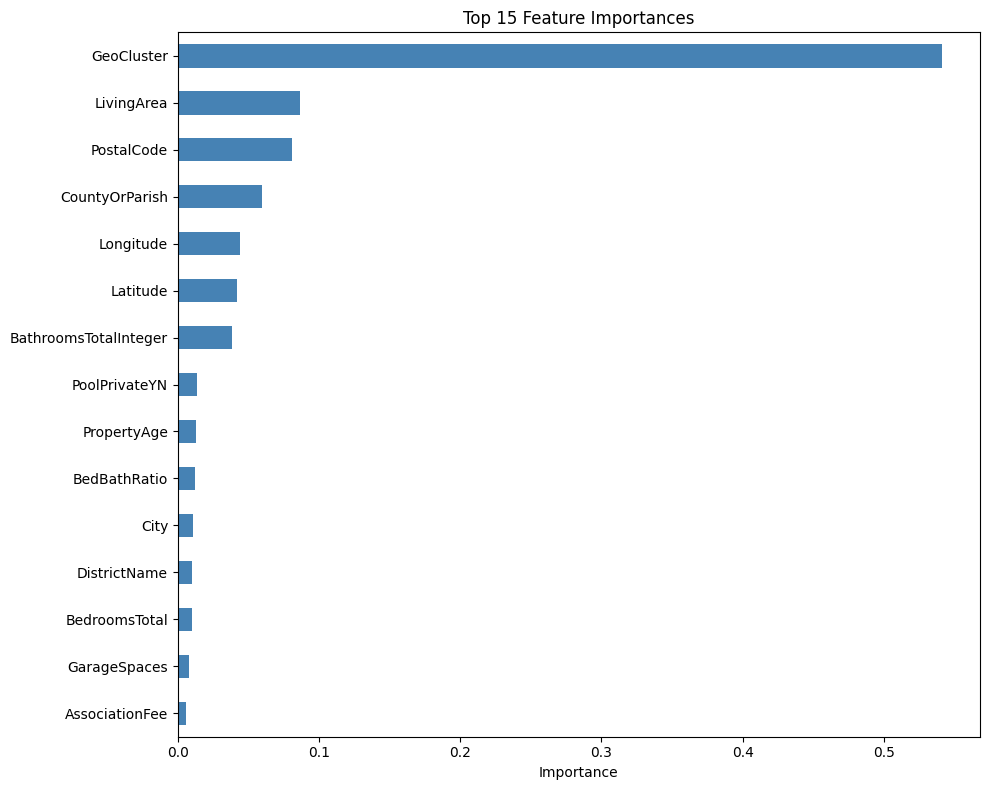

GeoCluster               0.540983
LivingArea               0.086175
PostalCode               0.080965
CountyOrParish           0.059279
Longitude                0.043830
Latitude                 0.041937
BathroomsTotalInteger    0.038492
PoolPrivateYN            0.013461
PropertyAge              0.012873
BedBathRatio             0.011897
City                     0.010431
DistrictName             0.010125
BedroomsTotal            0.010071
GarageSpaces             0.008109
AssociationFee           0.005792
dtype: float32


In [15]:
importances = pd.Series(model.feature_importances_, index=X_train.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances.head(15).plot(kind='barh', color='steelblue')
plt.xlabel('Importance')
plt.title('Top 15 Feature Importances')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(importances.head(15))

### Feature Importance Findings

GeoCluster is by far the most important feature in the final model, importance 0.54, over six times higher than the next feature, LivingArea. Location related features overall, GeoCluster, PostalCode, CountyOrParish, Longitude, and Latitude, dominate the top of the importance ranking, directly confirming the early EDA finding that raw property specs show weak correlation with price while location is the dominant driver.

DistrictName, while it provides complete coverage where HighSchoolDistrict was 25 percent missing, ranks relatively low in importance, similar to BedroomsTotal. This suggests that once GeoCluster, PostalCode, and CountyOrParish already capture most location signal, school district adds comparatively little additional predictive power on top of that.

## Section 4 - Section  SHAP Values

While feature importance shows which features matter most overall, SHAP values explain individual predictions, showing exactly how much each feature pushed a specific property's predicted price up or down. This is the level of explainability a real estate agent or buyer would actually want, not just "location matters" but "this specific home's price was pushed up by 45000 dollars because of its location cluster."

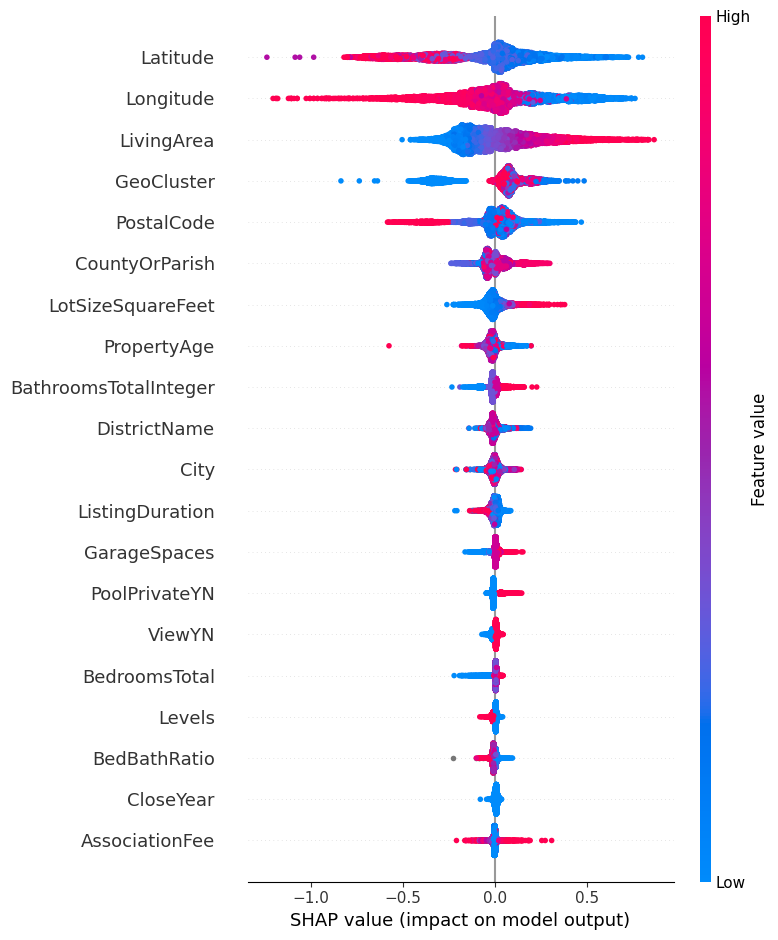

In [17]:
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png')
plt.show()

### SHAP Findings

SHAP values reveal a nuanced picture that complements the built in feature importance chart. While GeoCluster ranked highest in structural feature importance, SHAP shows Latitude and Longitude have the largest individual impact on specific predictions, with a clear pattern, lower values, corresponding to Southern California and coastal areas, consistently push predicted price up, while higher values push it down.

LivingArea shows the cleanest, most intuitive relationship, larger homes consistently push price up, smaller homes push it down, exactly as expected. GeoCluster's SHAP pattern is more categorical and less continuous than the coordinate features, consistent with it functioning as a location bucket rather than a smooth spatial gradient.

The difference between structural importance and SHAP impact illustrates an important distinction, importance measures how often a feature is used to make decisions, while SHAP measures how much that feature actually moves individual predictions, and the two do not always agree.